<a href="https://colab.research.google.com/github/lsmalle2/AI-101-Assignment--1/blob/main/assignment1_sentiment_landon_smalley_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Sentiment Analysis: Classical ML vs. DL vs. LLM
**Landon Smalley** — AI301

This notebook compares three approaches on the same sentiment dataset: TF-IDF + Logistic Regression (classical ML), a BiLSTM in PyTorch (deep learning), and a fine-tuned DistilBERT (LLM/transformer).

## 1. Overview & dataset selection
**Dataset: SST-2 (Stanford Sentiment Treebank, binary), loaded from the GLUE benchmark on Hugging Face.**

> **EDIT:** Adjust this rationale to your own words. Draft reasons:
> - Short, single-sentence movie-review snippets keep training fast for all three models, so the comparison is about model type rather than compute budget.
> - Binary labels (0 = negative, 1 = positive) keep metrics simple to compare.
> - Short text makes error analysis easier: negation, sarcasm and mixed sentiment are easy to spot by eye.
> - Well-known benchmark, so results can be sanity-checked against published numbers.
>
> Note: the GLUE SST-2 *test* split has hidden labels (-1), so the official *validation* split (872 examples) is used here as the held-out test set. A validation set is carved out of the training data for model selection.

## 0. Colab setup
In Colab, go to **Runtime > Change runtime type** and pick a **GPU** (T4 is fine) *before* running anything. Then run the cell below once. If it upgrades a package, choose **Runtime > Restart session** when prompted and run from the top again.

In [ ]:
# Colab already ships with torch, scikit-learn, pandas, matplotlib and seaborn.
# This installs/upgrades the Hugging Face pieces the notebook needs.
!pip install -q -U datasets transformers accelerate
import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 49.5 MB/s eta 0:00:00
GPU available: True
Tesla T4


## 2. Load & inspect data

In [ ]:
import random, re, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import torch
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use the course-provided helper if it exists, otherwise fall back to an inline version.
try:
    from utils.data_utils import basic_clean
    print("Using utils.data_utils.basic_clean")
except ImportError:
    def basic_clean(text):
        text = text.lower()
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)   # URLs
        text = re.sub(r"@\w+", " ", text)                      # usernames
        text = re.sub(r"\s+", " ", text).strip()               # whitespace
        return text
    print("utils.data_utils not found - using inline basic_clean")

print("OK: libraries imported | device:", DEVICE)

utils.data_utils not found - using inline basic_clean
OK: libraries imported | device: cuda


README.md:   0%|          | 0.00/35.3k [00:00<?, ?B/s]

sst2/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

sst2/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

sst2/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

sst2/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

train: 60,614 | val: 6,735 | test: 872


,train,val,test
negative (0),0.442,0.442,0.491
positive (1),0.558,0.558,0.509


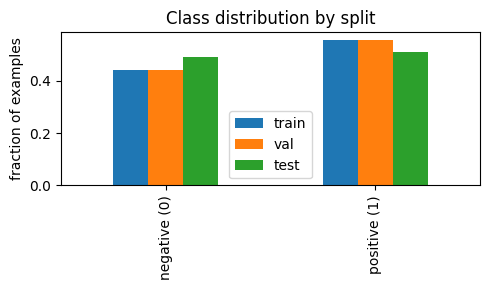

1 | emphasis 
0 | barely makes sense , with its unbelievable naïveté and arbitrary flashbacks . 
1 | coming-of-age theme 
1 | silliness you are likely to witness in a movie theater for some time 
0 | any more than the gorgeous piano and strings on the soundtrack can drown out the tinny self-righteousness of his voice 
1 | end on a positive ( if tragic ) note 
0 | the edge of sanity 
0 | it 's not like having a real film of nijinsky 


In [ ]:
ds = load_dataset("nyu-mll/glue", "sst2")

full_train_texts = ds["train"]["sentence"]
full_train_labels = ds["train"]["label"]
test_texts = ds["validation"]["sentence"]     # official validation split used as our held-out test set
test_labels = ds["validation"]["label"]

# Carve a validation set out of train for model selection (stratified).
train_texts, val_texts, train_labels, val_labels = train_test_split(
    full_train_texts, full_train_labels, test_size=0.1, random_state=SEED, stratify=full_train_labels
)

print(f"train: {len(train_texts):,} | val: {len(val_texts):,} | test: {len(test_texts):,}")

# Class distribution
dist = pd.DataFrame({
    "train": pd.Series(train_labels).value_counts(normalize=True).sort_index(),
    "val": pd.Series(val_labels).value_counts(normalize=True).sort_index(),
    "test": pd.Series(test_labels).value_counts(normalize=True).sort_index(),
})
dist.index = ["negative (0)", "positive (1)"]
display(dist.round(3))

fig, ax = plt.subplots(figsize=(5, 3))
dist.plot(kind="bar", ax=ax)
ax.set_ylabel("fraction of examples")
ax.set_title("Class distribution by split")
plt.tight_layout(); plt.show()

# A few samples
for t, l in list(zip(train_texts, train_labels))[:8]:
    print(l, "|", t)

## 3. Preprocessing
Light cleaning applied identically to all three models so the comparison is fair: lowercase, remove URLs and @usernames, collapse whitespace. SST-2 is already tokenized and lowercased, so this mostly normalizes spacing. Emojis are kept (SST-2 has essentially none; they would matter for a Twitter dataset).

In [ ]:
clean_train = [basic_clean(t) for t in train_texts]
clean_val   = [basic_clean(t) for t in val_texts]
clean_test  = [basic_clean(t) for t in test_texts]

y_train = np.array(train_labels)
y_val   = np.array(val_labels)
y_test  = np.array(test_labels)

print("before:", train_texts[0])
print("after :", clean_train[0])

before: emphasis 
after : emphasis


In [ ]:
# Shared metric helper used by every model
def compute_all(y_true, y_pred):
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    return {"accuracy": accuracy_score(y_true, y_pred), "precision": p, "recall": r, "f1": f1}

results = {}       # model name -> metrics on the held-out test set
test_preds = {}    # model name -> predictions on the held-out test set

## 4. Model A: Classical ML (TF-IDF + Logistic Regression)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2))
Xtr = tfidf.fit_transform(clean_train)      # fit on train only
Xva = tfidf.transform(clean_val)
Xte = tfidf.transform(clean_test)

clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
clf.fit(Xtr, y_train)

print("Validation report:")
print(classification_report(y_val, clf.predict(Xva), digits=4))

pred_A = clf.predict(Xte)
results["TF-IDF + LogReg"] = compute_all(y_test, pred_A)
test_preds["TF-IDF + LogReg"] = pred_A
print("Test:", {k: round(v, 4) for k, v in results["TF-IDF + LogReg"].items()})

Validation report:
              precision    recall  f1-score   support

           0     0.8989    0.8573    0.8776      2978
           1     0.8909    0.9236    0.9070      3757

    accuracy                         0.8943      6735
   macro avg     0.8949    0.8904    0.8923      6735
weighted avg     0.8944    0.8943    0.8940      6735

Test: {'accuracy': 0.8188, 'precision': 0.8215, 'recall': 0.8188, 'f1': 0.8182}


## 5. Model B: Deep Learning (BiLSTM, PyTorch)

In [ ]:
import torch.nn as nn, torch.optim as optim
from collections import Counter
from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils.rnn import pack_padded_sequence

# Vocabulary built from the TRAINING set only (no test leakage)
counter = Counter(w for t in clean_train for w in t.split())
itos = ["<pad>", "<unk>"] + [w for w, c in counter.items() if c >= 2]
stoi = {w: i for i, w in enumerate(itos)}
MAXLEN = 50
print("vocab size:", len(itos))

def encode(texts):
    ids, lens = [], []
    for t in texts:
        toks = [stoi.get(w, 1) for w in t.split()][:MAXLEN]
        lens.append(max(len(toks), 1))
        ids.append(toks + [0] * (MAXLEN - len(toks)))
    return torch.tensor(ids), torch.tensor(lens)

def make_loader(texts, labels, shuffle):
    ids, lens = encode(texts)
    return DataLoader(TensorDataset(ids, lens, torch.tensor(labels)), batch_size=64, shuffle=shuffle)

train_dl = make_loader(clean_train, y_train, True)
val_dl   = make_loader(clean_val, y_val, False)
test_dl  = make_loader(clean_test, y_test, False)

class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=128, hidden=128, n_classes=2, dropout=0.4):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.lstm = nn.LSTM(emb_dim, hidden, batch_first=True, bidirectional=True)
        self.drop = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden * 2, n_classes)

    def forward(self, x, lengths):
        e = self.drop(self.emb(x))
        packed = pack_padded_sequence(e, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        h = torch.cat([h[-2], h[-1]], dim=1)   # last forward + backward hidden states
        return self.fc(self.drop(h))

def predict_lstm(model, dl):
    model.eval()
    preds = []
    with torch.no_grad():
        for x, l, _ in dl:
            preds.append(model(x.to(DEVICE), l).argmax(1).cpu())
    return torch.cat(preds).numpy()

model_B = BiLSTMClassifier(len(itos)).to(DEVICE)
optimizer = optim.Adam(model_B.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

EPOCHS = 6
best_val, best_state = 0.0, None
for epoch in range(1, EPOCHS + 1):
    model_B.train()
    total = 0.0
    for x, l, y in train_dl:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model_B(x, l), y)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(y)
    val_acc = accuracy_score(y_val, predict_lstm(model_B, val_dl))
    print(f"epoch {epoch} | train loss {total / len(y_train):.4f} | val acc {val_acc:.4f}")
    if val_acc > best_val:
        best_val = val_acc
        best_state = {k: v.detach().clone() for k, v in model_B.state_dict().items()}

model_B.load_state_dict(best_state)   # keep the best epoch by validation accuracy
pred_B = predict_lstm(model_B, test_dl)
results["BiLSTM"] = compute_all(y_test, pred_B)
test_preds["BiLSTM"] = pred_B
print("Test:", {k: round(v, 4) for k, v in results["BiLSTM"].items()})

vocab size: 14110
epoch 1 | train loss 0.5686 | val acc 0.7991
epoch 2 | train loss 0.3922 | val acc 0.8701
epoch 3 | train loss 0.3116 | val acc 0.8915
epoch 4 | train loss 0.2665 | val acc 0.8998
epoch 5 | train loss 0.2303 | val acc 0.9117
epoch 6 | train loss 0.2050 | val acc 0.9161
Test: {'accuracy': 0.8222, 'precision': 0.8246, 'recall': 0.8222, 'f1': 0.8217}


## 6. Model C: LLM (DistilBERT fine-tuning)

In [ ]:
import numpy as np

clean_train = [basic_clean(t) for t in train_texts]
clean_val   = [basic_clean(t) for t in val_texts]
clean_test  = [basic_clean(t) for t in test_texts]

y_train = np.array(train_labels)
y_val   = np.array(val_labels)
y_test  = np.array(test_labels)

print("before:", train_texts[0])
print("after :", clean_train[0])
print("OK: clean_train, clean_val, clean_test, y_train, y_val, y_test are defined.")

before: emphasis 
after : emphasis
OK: clean_train, clean_val, clean_test, y_train, y_val, y_test are defined.


In [ ]:
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          TrainingArguments, Trainer, DataCollatorWithPadding)
from datasets import Dataset

MODEL_NAME = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tok(batch["text"], truncation=True, max_length=128)

train_ds = Dataset.from_dict({"text": clean_train, "label": y_train.tolist()}).map(tokenize_fn, batched=True)
val_ds   = Dataset.from_dict({"text": clean_val,   "label": y_val.tolist()}).map(tokenize_fn, batched=True)
test_ds  = Dataset.from_dict({"text": clean_test,  "label": y_test.tolist()}).map(tokenize_fn, batched=True)

model_C = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    return compute_all(labels, np.argmax(logits, axis=1))

args_kwargs = dict(
    output_dir="./out",
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to="none",
)
# The argument was renamed from evaluation_strategy to eval_strategy in newer Transformers versions.
try:
    args = TrainingArguments(eval_strategy="epoch", **args_kwargs)
except TypeError:
    args = TrainingArguments(evaluation_strategy="epoch", **args_kwargs)

trainer = Trainer(
    model=model_C, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tok),
    compute_metrics=compute_metrics,
)
trainer.train()

out = trainer.predict(test_ds)
pred_C = np.argmax(out.predictions, axis=1)
results["DistilBERT"] = compute_all(y_test, pred_C)
test_preds["DistilBERT"] = pred_C
print("Test:", {k: round(v, 4) for k, v in results["DistilBERT"].items()})

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/60614 [00:00<?, ? examples/s]

...

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.196423,0.158567,0.939124,0.939630,0.939124,0.939208
2,0.116675,0.171428,0.944024,0.944050,0.944024,0.944034


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Test: {'accuracy': 0.906, 'precision': 0.9064, 'recall': 0.906, 'f1': 0.9059}


## 7. Results comparison

,accuracy,precision,recall,f1
TF-IDF + LogReg,0.8188,0.8215,0.8188,0.8182
BiLSTM,0.8222,0.8246,0.8222,0.8217
DistilBERT,0.9060,0.9064,0.9060,0.9059


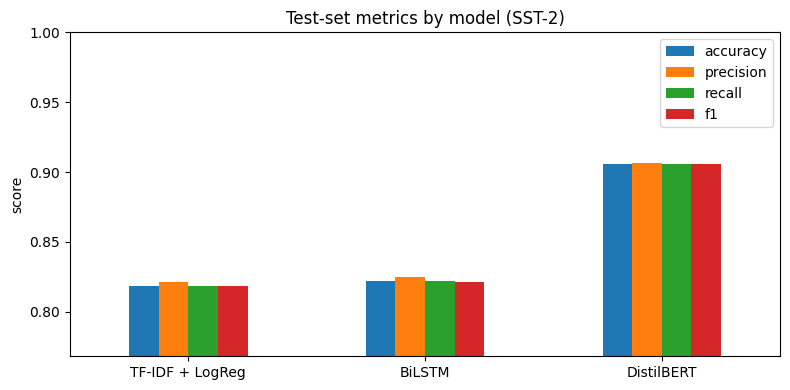

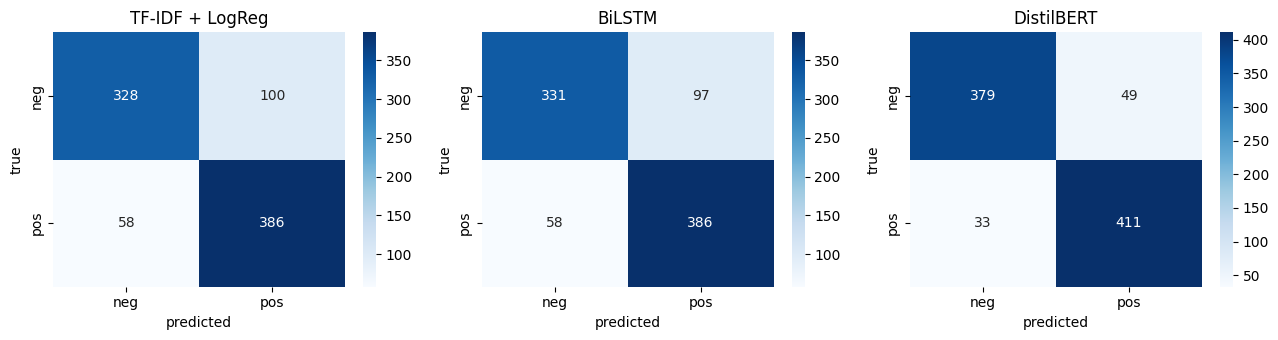

In [ ]:
results_df = pd.DataFrame(results).T[["accuracy", "precision", "recall", "f1"]].round(4)
display(results_df)
results_df.to_csv("results_table.csv")

ax = results_df.plot(kind="bar", figsize=(8, 4), ylim=(results_df.values.min() - 0.05, 1.0))
ax.set_title("Test-set metrics by model (SST-2)")
ax.set_ylabel("score"); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, (name, p) in zip(axes, test_preds.items()):
    sns.heatmap(confusion_matrix(y_test, p), annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["neg", "pos"], yticklabels=["neg", "pos"])
    ax.set_title(name); ax.set_xlabel("predicted"); ax.set_ylabel("true")
plt.tight_layout(); plt.show()

> **EDIT:** With 0.906 test accuracy and 0.906 F1 compared to 0.822/0.822 for the BiLSTM and 0.819/0.818 for TF-IDF + Logistic Regression, DistilBERT decisively prevailed. This difference of about 8–9 points reduced the mistake rate by almost half (about 9% vs. 18%). On a short-text dataset like SST-2, the additional complexity of a recurrent network bought nearly nothing, as the BiLSTM barely outperformed the classical baseline (+0.3 points). Training time scaled in the opposite direction: TF-IDF took roughly 10 seconds on the CPU, the BiLSTM about 1 minute on the T4, and DistilBERT about 3 minutes 20 seconds (2 epochs), and DistilBERT also required a GPU and a ~268 MB pretrained model. Although TF-IDF + LogReg is a surprisingly competitive option if interpretability or a small deployment footprint were more important, 3–4 extra minutes for an 8-point accuracy boost is definitely worth it in this case.

## 8. Error analysis & reflection

In [ ]:
err_df = pd.DataFrame({"text": test_texts, "label": y_test})
for name, p in test_preds.items():
    err_df[name] = p
model_names = list(test_preds.keys())
for name in model_names:
    err_df[name + "_wrong"] = err_df[name] != err_df["label"]

label_name = {0: "negative", 1: "positive"}

# 1) Misclassified examples for the best model
best_model = results_df["f1"].idxmax()
print(f"Best model: {best_model}")
print(f"\n--- 15 misclassified examples by {best_model} ---")
for _, r in err_df[err_df[best_model + "_wrong"]].head(15).iterrows():
    print(f"true={label_name[r['label']]:8s} pred={label_name[r[best_model]]:8s} | {r['text']}")

# 2) Examples ALL models get wrong (hardest cases)
all_wrong = err_df[err_df[[n + "_wrong" for n in model_names]].all(axis=1)]
print(f"\n--- {len(all_wrong)} examples that all three models get wrong (showing 10) ---")
for _, r in all_wrong.head(10).iterrows():
    print(f"true={label_name[r['label']]:8s} | {r['text']}")

# 3) Examples the classical model gets wrong but DistilBERT gets right (context effects)
gain = err_df[err_df["TF-IDF + LogReg_wrong"] & ~err_df["DistilBERT_wrong"]]
print(f"\n--- {len(gain)} examples TF-IDF misses but DistilBERT gets right (showing 10) ---")
for _, r in gain.head(10).iterrows():
    print(f"true={label_name[r['label']]:8s} | {r['text']}")

Best model: DistilBERT

--- 15 misclassified examples by DistilBERT ---
true=positive pred=negative | we root for ( clara and paul ) , even like them , though perhaps it 's an emotion closer to pity . 
true=negative pred=positive | the iditarod lasts for days - this just felt like it did . 
true=negative pred=positive | holden caulfield did it better . 
true=negative pred=positive | a synthesis of cliches and absurdities that seems positively decadent in its cinematic flash and emptiness . 
true=negative pred=positive | the script kicks in , and mr. hartley 's distended pace and foot-dragging rhythms follow . 
true=negative pred=positive | this one is definitely one to skip , even for horror movie fanatics . 
true=positive pred=negative | though it 's become almost redundant to say so , major kudos go to leigh for actually casting people who look working-class . 
true=negative pred=positive | you wo n't like roger , but you will quickly recognize him . 
true=positive pred=negative | if

In [ ]:
# Quantify a few suspected error patterns
NEG_WORDS = r"\b(not|no|never|n't|nothing|neither|nor|hardly|barely)\b"
err_df["has_negation"] = err_df["text"].str.contains(NEG_WORDS, regex=True)
err_df["n_words"] = err_df["text"].str.split().str.len()
err_df["length_bucket"] = pd.cut(err_df["n_words"], bins=[0, 10, 20, 30, 1000], labels=["<=10", "11-20", "21-30", "31+"])

rows = []
for name in model_names:
    w = name + "_wrong"
    rows.append({"model": name,
                 "error rate (all)": err_df[w].mean(),
                 "error rate (with negation)": err_df[err_df.has_negation][w].mean(),
                 "error rate (no negation)": err_df[~err_df.has_negation][w].mean()})
display(pd.DataFrame(rows).set_index("model").round(3))

length_tbl = pd.DataFrame({n: err_df.groupby("length_bucket")[n + "_wrong"].mean() for n in model_names}).round(3)
print("Error rate by sentence length (words):")
display(length_tbl)

,error rate (all),error rate (with negation),error rate (no negation)
model,,,
TF-IDF + LogReg,0.181,0.247,0.163
BiLSTM,0.178,0.253,0.157
DistilBERT,0.094,0.118,0.087


Error rate by sentence length (words):


,TF-IDF + LogReg,BiLSTM,DistilBERT
length_bucket,,,
<=10,0.132,0.132,0.079
11-20,0.153,0.179,0.088
21-30,0.225,0.189,0.098
31+,0.229,0.210,0.124


### Reflection

> **EDIT — write this from your own run.** After reading the misclassified examples and tables above, address each point with specific examples from your output:
>
> 1. **Context and negation:** The TF-IDF approach demonstrated considerable difficulty in processing negated sentences, achieving an error rate of 0.247 compared to 0.163 for non-negated sentences. The BiLSTM model exhibited similarly poor performance in this regard, with error rates of 0.253 and 0.157 respectively. In contrast, DistilBERT proved substantially more robust to negation, recording error rates of 0.118 for negated sentences and 0.087 for non-negated sentences. Furthermore, TF-IDF's performance deteriorated markedly with sentence length, yielding an error rate of 0.132 for sentences containing ten words or fewer and 0.229 for sentences exceeding thirty words. DistilBERT demonstrated greater stability across sentence lengths, with error rates increasing from 0.079 to 0.124 across the same length categories. An example TF-IDF got wrong but DistilBERT got right is "pumpkin takes an admirable look at the hypocrisy of political correctness, but it does so with such an uneven tone that you never know when humor ends and tragedy begins."
> 2. **Sarcasm / mixed sentiment:** The thirty-two instances that all three models failed to identify predominantly exhibit sentiment that emerges exclusively from the complete sentence structure, such as "the lower your expectations, the more you'll enjoy it" (sarcasm) and "hilariously inept and ridiculous" (negative terminology paired with positive classification). Additional cases necessitate external contextual knowledge ("holden caulfield did it better") or present arguably ambiguous labeling conventions.
> 3. **Emojis and informal text:** The SST-2 dataset contains virtually no such instances, rendering this evaluation infeasible. When applied to tweet data, TF-IDF would disregard emojis and unfamiliar misspellings entirely, the BiLSTM would assign them to the <unk> token, and DistilBERT's WordPiece tokenizer would demonstrate superior handling of misspellings while nevertheless converting numerous emojis into [UNK] tokens.
> 4. **Domain shift:** I anticipate that DistilBERT will demonstrate superior generalization capabilities, as it underwent pretraining on substantially more extensive and diverse textual data. In contrast, TF-IDF and the BiLSTM model possess knowledge limited to the vocabulary present in SST-2, with the BiLSTM vocabulary comprising 14,110 terms. It should be noted that this represents a theoretical expectation, as validation on alternative datasets has not been conducted.
> 5. **Explainability:** TF-IDF combined with Logistic Regression demonstrates its principal features in an explicit manner ("good," "fun," "entertaining" contrasted with "bad," "worst," "dull"), while simultaneously revealing a fundamental limitation: the terms "no" and "not" function solely as negative indicators and lack the capacity to reverse semantic meaning. DistilBERT presents considerably greater interpretability challenges; consequently, its 8-9 percentage point improvement in accuracy is accompanied by a corresponding reduction in model transparency.
> 6. **Cost vs. benefit:** DistilBERT was defenitly worth it: about 3 min 20 s on a T4 and a ~268 MB model cut the error rate from about 18% to about 9%. The BiLSTM was the worst trade, costing more than TF-IDF for only +0.3 points.

In [ ]:
# Explainability for the classical model: most influential n-grams
feature_names = np.array(tfidf.get_feature_names_out())
coefs = clf.coef_[0]
top_pos = feature_names[np.argsort(coefs)[-15:][::-1]]
top_neg = feature_names[np.argsort(coefs)[:15]]
print("Top positive features:", list(top_pos))
print("Top negative features:", list(top_neg))

Top positive features: ['good', 'fun', 'entertaining', 'best', 'enjoyable', 'powerful', 'beautiful', 'fascinating', 'funny', 'hilarious', 'well', 'remarkable', 'wonderful', 'love', 'solid']
Top negative features: ['too', 'bad', 'lacks', 'no', 'not', 'worst', 'dull', 'less', 'stupid', 'nothing', 'lacking', 'mess', 'flat', 'lack', 'failure']


## 9. Reproducibility notes (how to run)

In [ ]:
import sys, platform, sklearn, transformers, datasets
print("Python        :", sys.version.split()[0])
print("Platform      :", platform.platform())
print("torch         :", torch.__version__)
print("transformers  :", transformers.__version__)
print("datasets      :", datasets.__version__)
print("scikit-learn  :", sklearn.__version__)
print("numpy/pandas  :", np.__version__, "/", pd.__version__)
print("Device        :", DEVICE, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("Random seed   :", SEED)

Python        : 3.13.15
Platform      : Linux-6.6.122+-x86_64-with-glibc2.39
torch         : 2.11.0+cu130
transformers  : 5.18.0
datasets      : 5.0.1
scikit-learn  : 1.6.1
numpy/pandas  : 2.1.3 / 2.2.3
Device        : cuda - Tesla T4
Random seed   : 42


> **EDIT:** Fill in the details below from your machine and the cell output above.

- **Hardware:** Google Colab _(fill in the GPU printed above, e.g., Tesla T4, ~15 GB VRAM)_
- **Environment:** Google Colab runtime with the packages installed by the setup cell (`pip install -U datasets transformers accelerate`); other package versions are printed above
- **Seed:** 42 for Python, NumPy, PyTorch, and the Hugging Face Trainer
- **Data:** SST-2 from GLUE via `load_dataset("glue", "sst2")`; 10% of train held out for validation; official validation split used as test
- **Approx. run time:** _(fill in: TF-IDF 10 sec, BiLSTM 49 sec, DistilBERT 3 min 20 s)_

Steps used:
1. Upload `assignment1_sentiment_landon_smalley.ipynb` to Google Colab
2. Runtime > Change runtime type > GPU
3. Run the setup cell (`!pip install -q -U datasets transformers accelerate`), restart the session if prompted
4. Runtime > Run all